In [1]:
# --- CELL 1 ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore') # Hides annoying pandas layout warnings

# 1. Connect to Postgres
load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

# 2. Load the raw mart (with the source column)
query = "SELECT * FROM fct_city_daily_aqi ORDER BY reading_date ASC"
df_raw = pd.read_sql(query, engine)

# 3. Create the UNIFIED dataframe for general trends (ignoring source to merge the Nulls)
df_unified = df_raw.groupby(['city', 'reading_date']).mean(numeric_only=True).reset_index()

print(f"✅ Loaded {len(df_raw)} raw source rows.")
print(f"✅ Unified into {len(df_unified)} daily city records for analysis.")
display(df_unified.head(10))

✅ Loaded 1788 raw source rows.
✅ Unified into 1714 daily city records for analysis.


,city,reading_date,avg_pm25,avg_pm10,avg_so2,avg_no2,avg_no,avg_co,avg_nh3,avg_o3,max_pollutant_value,active_stations
0,Ahmedabad,2025-08-28 18:30:00+00:00,36.06,65.70,27.77,53.41,35.14,2.47,NaN,NaN,95.5700,1.0
1,Ahmedabad,2026-04-14 18:30:00+00:00,47.06,146.29,81.40,48.59,17.54,0.85,NaN,38.86,756.4726,8.0
2,Ahmedabad,2026-04-15 18:30:00+00:00,39.62,112.79,94.06,55.33,23.11,1.05,NaN,36.80,701.4526,8.0
3,Ahmedabad,2026-04-16 18:30:00+00:00,44.91,135.75,92.23,84.78,35.91,1.14,NaN,30.99,660.7640,8.0
4,Ahmedabad,2026-04-17 18:30:00+00:00,39.99,113.05,80.87,46.09,18.70,0.77,NaN,32.16,595.5260,8.0
5,Ahmedabad,2026-04-18 18:30:00+00:00,35.80,121.61,68.98,49.89,18.87,0.65,NaN,32.98,823.7000,8.0
6,Ahmedabad,2026-04-19 18:30:00+00:00,44.67,132.86,84.03,57.09,24.25,0.94,NaN,29.94,444.6327,8.0
7,Ahmedabad,2026-04-20 18:30:00+00:00,30.99,98.69,67.96,49.28,16.31,0.66,NaN,34.08,587.2730,8.0
8,Ahmedabad,2026-04-21 18:30:00+00:00,41.00,117.92,96.91,63.69,14.83,0.88,NaN,41.85,772.7952,8.0
9,Ahmedabad,2026-04-22 18:30:00+00:00,36.66,111.54,75.72,93.60,21.65,0.94,NaN,29.88,595.7156,8.0


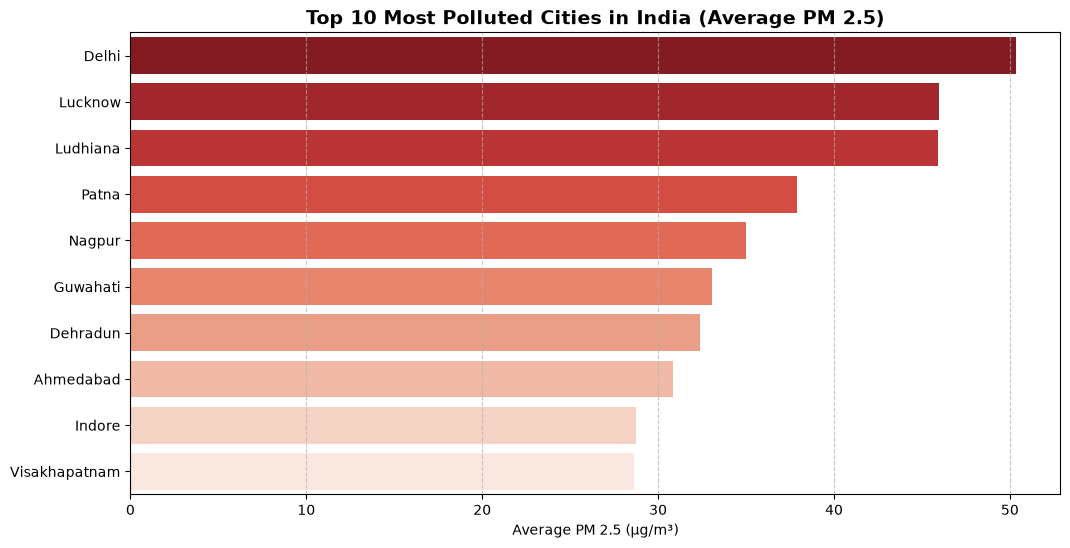

📝 INSIGHT 1: Delhi is the most polluted city in the dataset, averaging 50.4 µg/m³ of PM2.5.


In [2]:
# --- CELL 2 ---
plt.figure(figsize=(12, 6))

# Sort cities by highest average PM2.5
top_cities = df_unified.groupby('city')['avg_pm25'].median().sort_values(ascending=False).head(10)

sns.barplot(x=top_cities.values, y=top_cities.index, palette="Reds_r")
plt.title("Top 10 Most Polluted Cities in India (Average PM 2.5)", fontsize=14, fontweight='bold')
plt.xlabel("Average PM 2.5 (µg/m³)")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(f"📝 INSIGHT 1: {top_cities.index[0]} is the most polluted city in the dataset, averaging {top_cities.values[0]:.1f} µg/m³ of PM2.5.")

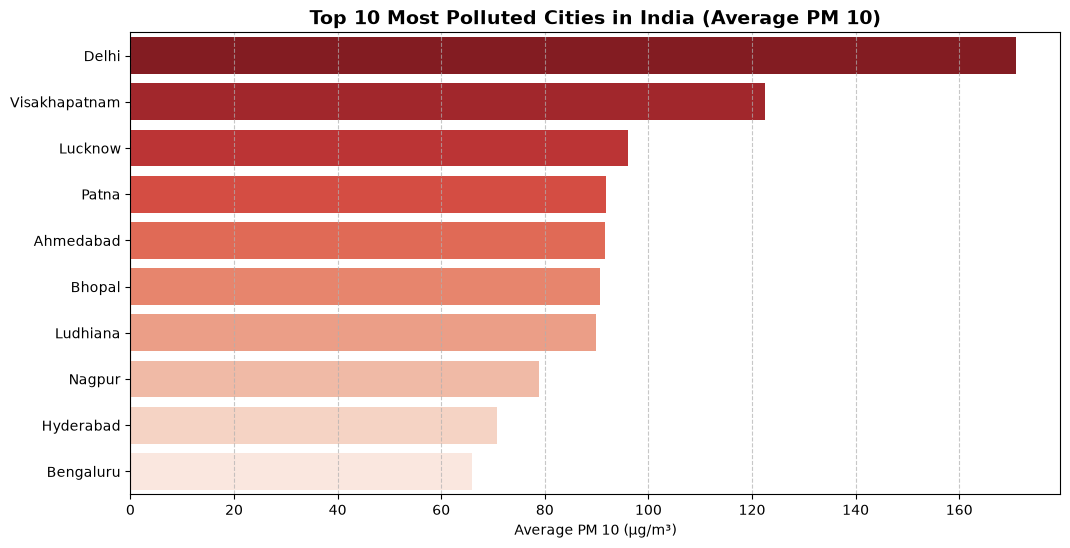

📝 INSIGHT 1: Delhi is the most polluted city in the dataset, averaging 171.0 µg/m³ of PM10.


In [3]:
# --- CELL 2 ---
plt.figure(figsize=(12, 6))

# Sort cities by highest average PM10
top_cities = df_unified.groupby('city')['avg_pm10'].median().sort_values(ascending=False).head(10)

sns.barplot(x=top_cities.values, y=top_cities.index, palette="Reds_r")
plt.title("Top 10 Most Polluted Cities in India (Average PM 10)", fontsize=14, fontweight='bold')
plt.xlabel("Average PM 10 (µg/m³)")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(f"📝 INSIGHT 1: {top_cities.index[0]} is the most polluted city in the dataset, averaging {top_cities.values[0]:.1f} µg/m³ of PM10.")

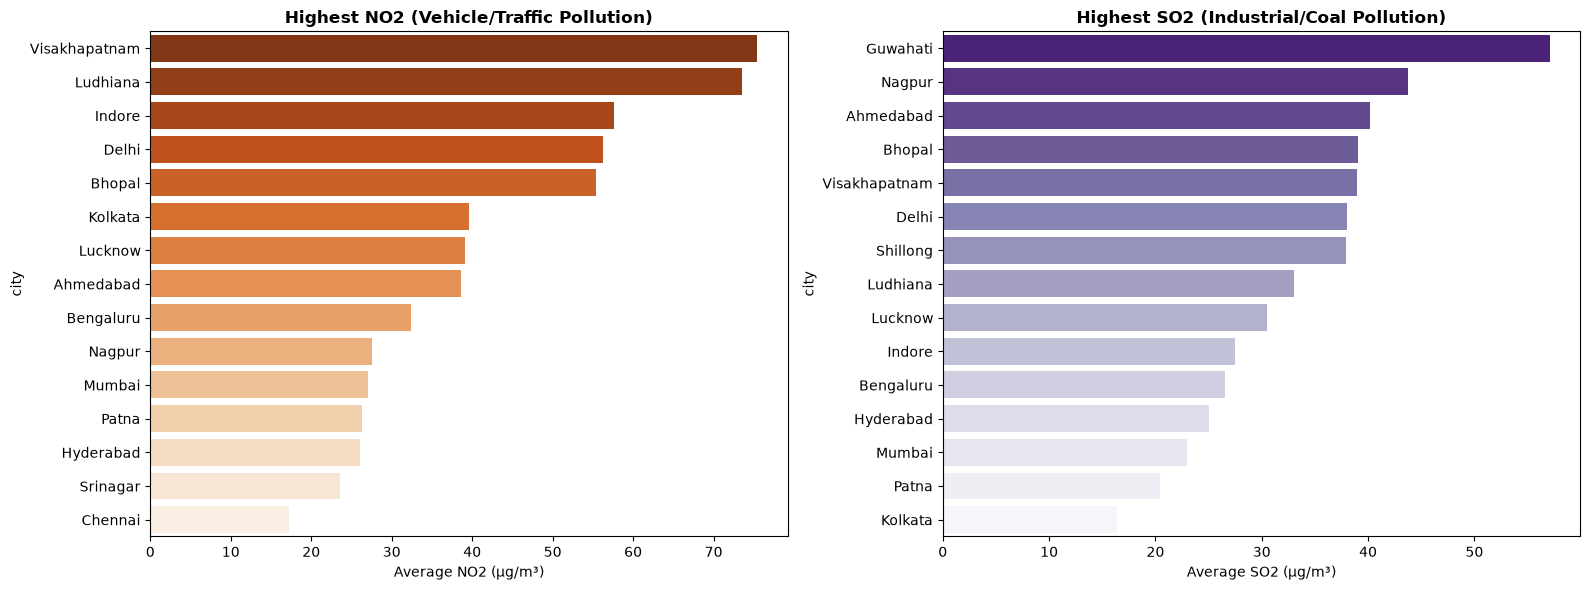

📝 INSIGHT 2: After filtering out broken sensor spikes, we can accurately see the real industrial vs traffic capitals!


In [9]:
# --- UPDATED CELL 3 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Remove broken sensor readings (impossible outliers) before averaging
df_sane = df_unified[(df_unified['avg_no2'] < 2000) & (df_unified['avg_so2'] < 10000)]

# Top 15 for NO2 (Traffic)
top_no2 = df_sane.groupby('city')['avg_no2'].median().sort_values(ascending=False).head(15)
sns.barplot(x=top_no2.values, y=top_no2.index, palette="Oranges_r", ax=axes[0])
axes[0].set_title("Highest NO2 (Vehicle/Traffic Pollution)", fontweight='bold')
axes[0].set_xlabel("Average NO2 (µg/m³)")

# Top 15 for SO2 (Industry/Coal)
top_so2 = df_sane.groupby('city')['avg_so2'].median().sort_values(ascending=False).head(15)
sns.barplot(x=top_so2.values, y=top_so2.index, palette="Purples_r", ax=axes[1])
axes[1].set_title("Highest SO2 (Industrial/Coal Pollution)", fontweight='bold')
axes[1].set_xlabel("Average SO2 (µg/m³)")

plt.tight_layout()
plt.show()

print("📝 INSIGHT 2: After filtering out broken sensor spikes, we can accurately see the real industrial vs traffic capitals!")

In [10]:
# --- RIGOROUS EDA PIPELINE ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# 1. Connect to Postgres
load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

# 2. Query the HOURLY staging data (NOT the daily mart) to do our own rigorous aggregation
query = """
    SELECT city, station, pollutant, pollutant_value, reading_time_utc 
    FROM stg_aqi_readings 
    WHERE pollutant IN ('NO2', 'SO2')
"""
df_hourly = pd.read_sql(query, engine)

# Convert timestamp to a plain Date column
df_hourly['reading_date'] = pd.to_datetime(df_hourly['reading_time_utc']).dt.floor('D')


# ==============================================================================
# STAGE 1: Sensor-Day Mean & Minimum Coverage Rule
# ==============================================================================
# Group by individual sensor and day
sensor_daily = df_hourly.groupby(['city', 'station', 'pollutant', 'reading_date'])['pollutant_value'].agg(['mean', 'count']).reset_index()

# RULE: A sensor must have at least 4 readings in a day to be considered a "valid day"
# (This prevents a sensor with a single 3 AM reading from representing the whole day)
MIN_READINGS_PER_DAY = 4
sensor_daily_valid = sensor_daily[sensor_daily['count'] >= MIN_READINGS_PER_DAY]


# ==============================================================================
# STAGE 2: City-Day Median
# ==============================================================================
# Find the typical sensor reading for the city on that day, and count active sensors
city_daily = sensor_daily_valid.groupby(['city', 'pollutant', 'reading_date']).agg(
    city_day_median=('mean', 'median'),
    active_sensors=('station', 'nunique')
).reset_index()


# ==============================================================================
# STAGE 3: Period Median & Context Columns
# ==============================================================================
final_eda = city_daily.groupby(['city', 'pollutant']).agg(
    median_concentration=('city_day_median', 'median'),
    avg_active_sensors=('active_sensors', 'mean'), # Average number of sensors working on a given day
    valid_day_count=('reading_date', 'nunique')
).reset_index()

# Clean up the output formatting
final_eda['median_concentration'] = final_eda['median_concentration'].round(1)
final_eda['avg_active_sensors'] = final_eda['avg_active_sensors'].round(0).astype(int)

# Sort and display results!
no2_results = final_eda[final_eda['pollutant'] == 'NO2'].sort_values(by='median_concentration', ascending=False)
so2_results = final_eda[final_eda['pollutant'] == 'SO2'].sort_values(by='median_concentration', ascending=False)

print("🏆 MOST RIGOROUS NO2 RANKINGS (Traffic/Vehicle Pollution)")
display(no2_results[['city', 'median_concentration', 'avg_active_sensors', 'valid_day_count']].head(10).reset_index(drop=True))

print("\n🏭 MOST RIGOROUS SO2 RANKINGS (Industrial/Coal Pollution)")
display(so2_results[['city', 'median_concentration', 'avg_active_sensors', 'valid_day_count']].head(10).reset_index(drop=True))

🏆 MOST RIGOROUS NO2 RANKINGS (Traffic/Vehicle Pollution)


,city,median_concentration,avg_active_sensors,valid_day_count
0,Visakhapatnam,40.7,1,90
1,Ludhiana,39.4,1,84
2,Delhi,29.1,45,90
3,Lucknow,21.6,6,90
4,Kolkata,18.4,6,90
5,Bengaluru,17.5,9,90
6,Bhopal,16.3,4,90
7,Ahmedabad,15.8,8,90
8,Indore,15.1,5,90
9,Nagpur,13.9,4,90



🏭 MOST RIGOROUS SO2 RANKINGS (Industrial/Coal Pollution)


,city,median_concentration,avg_active_sensors,valid_day_count
0,Guwahati,24.1,4,90
1,Shillong,15.1,2,89
2,Visakhapatnam,14.5,1,90
3,Delhi,14.3,36,90
4,Bhopal,13.8,4,90
5,Nagpur,13.3,4,90
6,Ludhiana,12.8,1,84
7,Hyderabad,9.7,12,90
8,Bengaluru,9.2,9,90
9,Lucknow,9.0,6,90


In [11]:
# --- THE ULTIMATE RIGOROUS EDA PIPELINE ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# 1. Connect to Postgres
load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

# 2. Query the HOURLY staging data
query = """
    SELECT city, station, pollutant, pollutant_value, reading_time_utc 
    FROM stg_aqi_readings 
    WHERE pollutant IN ('NO2', 'SO2', 'PM2.5')
"""
df_hourly = pd.read_sql(query, engine)

# Convert timestamp to a plain Date column
df_hourly['reading_date'] = pd.to_datetime(df_hourly['reading_time_utc']).dt.floor('D')


# ==============================================================================
# STAGE 1: Sensor-Day Mean & 75% Completeness Rule (EPA Standard)
# ==============================================================================
# Group by individual sensor and day
sensor_daily = df_hourly.groupby(['city', 'station', 'pollutant', 'reading_date'])['pollutant_value'].agg(['mean', 'count']).reset_index()

# RULE: A sensor must have at least 18 hourly readings (~75% of a day) to be a valid day
MIN_READINGS_PER_DAY = 18
sensor_daily_valid = sensor_daily[sensor_daily['count'] >= MIN_READINGS_PER_DAY]


# ==============================================================================
# STAGE 2: City-Day Median
# ==============================================================================
# Find the typical sensor reading for the city on that day, and count active sensors
city_daily = sensor_daily_valid.groupby(['city', 'pollutant', 'reading_date']).agg(
    city_day_median=('mean', 'median'),
    active_sensors=('station', 'nunique')
).reset_index()


# ==============================================================================
# STAGE 3: Period Distribution & Evidence Depth
# ==============================================================================
final_eda = city_daily.groupby(['city', 'pollutant']).agg(
    # Central Tendency
    median_conc=('city_day_median', 'median'),
    mean_conc=('city_day_median', 'mean'),
    
    # The "Tails" (Extreme Events)
    p90_conc=('city_day_median', lambda x: x.quantile(0.90)),
    p95_conc=('city_day_median', lambda x: x.quantile(0.95)),
    
    # Evidence Depth
    avg_active_sensors=('active_sensors', 'mean'),
    valid_day_count=('reading_date', 'nunique'),
    total_sensor_days=('active_sensors', 'sum')
).reset_index()

# Clean up formatting for display
for col in ['median_conc', 'mean_conc', 'p90_conc', 'p95_conc']:
    final_eda[col] = final_eda[col].round(1)
final_eda['avg_active_sensors'] = final_eda['avg_active_sensors'].round(1)

# Separate into dataframes for easier viewing
pm25_results = final_eda[final_eda['pollutant'] == 'PM2.5'].sort_values(by='median_conc', ascending=False)
no2_results  = final_eda[final_eda['pollutant'] == 'NO2'].sort_values(by='median_conc', ascending=False)
so2_results  = final_eda[final_eda['pollutant'] == 'SO2'].sort_values(by='median_conc', ascending=False)

print("🌫️ STRICT PM2.5 RANKINGS (Smog/Dust)")
display(pm25_results.head(10).reset_index(drop=True))

print("\n🚗 STRICT NO2 RANKINGS (Traffic/Vehicle Pollution)")
display(no2_results.head(10).reset_index(drop=True))

print("\n🏭 STRICT SO2 RANKINGS (Industrial/Coal Pollution)")
display(so2_results.head(10).reset_index(drop=True))

🌫️ STRICT PM2.5 RANKINGS (Smog/Dust)


,city,pollutant,median_conc,mean_conc,p90_conc,p95_conc,avg_active_sensors,valid_day_count,total_sensor_days
0,Delhi,PM2.5,49.0,51.5,79.3,83.7,44.1,91,4011
1,Lucknow,PM2.5,46.6,45.8,68.6,73.9,5.9,90,527
2,Ludhiana,PM2.5,45.8,45.7,54.7,56.7,1.0,83,83
3,Patna,PM2.5,36.1,37.6,45.4,59.3,5.9,90,527
4,Dehradun,PM2.5,33.7,32.7,47.6,50.7,1.0,84,84
5,Nagpur,PM2.5,33.5,33.0,46.5,52.5,4.9,91,442
6,Ahmedabad,PM2.5,29.2,31.4,41.7,45.2,7.6,90,686
7,Guwahati,PM2.5,29.0,30.6,39.8,41.9,3.3,89,295
8,Hyderabad,PM2.5,28.6,28.0,34.0,36.5,11.5,90,1035
9,Visakhapatnam,PM2.5,27.4,27.1,39.5,41.9,1.0,88,88



🚗 STRICT NO2 RANKINGS (Traffic/Vehicle Pollution)


,city,pollutant,median_conc,mean_conc,p90_conc,p95_conc,avg_active_sensors,valid_day_count,total_sensor_days
0,Visakhapatnam,NO2,40.3,39.6,55.4,57.7,1.0,88,88
1,Ludhiana,NO2,39.5,39.3,49.5,52.5,1.0,83,83
2,Delhi,NO2,29.0,30.3,41.9,48.0,43.5,90,3914
3,Lucknow,NO2,21.6,21.2,24.7,25.0,5.9,90,530
4,Kolkata,NO2,18.4,19.6,24.5,26.8,5.8,90,522
5,Bengaluru,NO2,17.4,17.3,19.5,20.3,8.2,90,737
6,Bhopal,NO2,16.3,18.5,26.7,29.4,3.8,90,342
7,Ahmedabad,NO2,15.8,17.4,26.2,30.1,7.6,90,680
8,Indore,NO2,15.2,19.3,30.4,44.1,4.5,90,404
9,Nagpur,NO2,14.2,16.6,26.4,29.8,4.0,90,356



🏭 STRICT SO2 RANKINGS (Industrial/Coal Pollution)


,city,pollutant,median_conc,mean_conc,p90_conc,p95_conc,avg_active_sensors,valid_day_count,total_sensor_days
0,Guwahati,SO2,25.0,21.1,29.1,29.5,3.5,89,314
1,Shillong,SO2,14.9,13.2,17.7,17.9,1.6,88,141
2,Visakhapatnam,SO2,14.4,16.9,31.9,34.6,1.0,88,88
3,Delhi,SO2,14.4,14.7,22.9,23.5,35.6,90,3202
4,Bhopal,SO2,13.7,14.1,19.1,19.9,3.8,90,342
5,Nagpur,SO2,13.6,14.1,22.4,29.9,4.0,90,356
6,Ludhiana,SO2,12.9,13.3,16.4,18.4,1.0,83,83
7,Hyderabad,SO2,9.8,9.5,11.7,12.0,11.5,90,1037
8,Bengaluru,SO2,9.6,9.6,12.3,13.1,8.7,90,780
9,Lucknow,SO2,9.1,9.5,13.3,14.2,5.8,90,524


🌫️ STRICT PM2.5 RANKINGS (Smog/Dust)


,city,pollutant,median_conc,mean_conc,p90_conc,p95_conc,avg_active_sensors,valid_day_count,total_sensor_days
0,Delhi,PM2.5,49.0,50.4,77.4,82.4,39.7,90,3571
1,Lucknow,PM2.5,45.6,45.7,64.8,74.3,5.4,84,456
2,Ludhiana,PM2.5,45.6,45.8,54.9,57.7,1.0,76,76
3,Patna,PM2.5,37.4,38.6,46.0,55.7,5.1,84,426
4,Dehradun,PM2.5,34.4,32.8,46.5,50.9,1.0,72,72
5,Nagpur,PM2.5,33.2,32.7,46.3,51.6,4.5,90,406
6,Visakhapatnam,PM2.5,30.0,28.0,40.0,42.2,1.0,77,77
7,Ahmedabad,PM2.5,29.4,31.1,42.0,42.8,7.2,84,608
8,Guwahati,PM2.5,29.2,30.6,39.5,44.9,2.7,84,229
9,Hyderabad,PM2.5,29.0,27.8,33.8,36.7,9.9,84,832



🚗 STRICT NO2 RANKINGS (Traffic/Vehicle Pollution)


,city,pollutant,median_conc,mean_conc,p90_conc,p95_conc,avg_active_sensors,valid_day_count,total_sensor_days
0,Visakhapatnam,NO2,40.0,39.3,55.2,60.0,1.0,80,80
1,Ludhiana,NO2,39.6,39.5,49.1,52.3,1.0,76,76
2,Delhi,NO2,28.8,29.8,41.4,46.7,41.8,84,3513
3,Lucknow,NO2,21.7,21.4,25.1,25.3,5.6,84,469
4,Kolkata,NO2,18.6,19.6,24.6,27.0,5.5,84,465
5,Bengaluru,NO2,17.1,17.2,20.1,20.6,6.9,84,581
6,Bhopal,NO2,16.1,18.9,27.8,29.8,3.4,84,282
7,Ahmedabad,NO2,15.7,17.4,26.1,31.3,7.2,84,606
8,Srinagar,NO2,15.5,15.3,20.1,20.3,1.3,56,71
9,Indore,NO2,15.4,21.2,44.9,52.0,4.0,84,339



🏭 STRICT SO2 RANKINGS (Industrial/Coal Pollution)


,city,pollutant,median_conc,mean_conc,p90_conc,p95_conc,avg_active_sensors,valid_day_count,total_sensor_days
0,Guwahati,SO2,26.3,22.1,29.8,30.8,3.0,84,256
1,Shillong,SO2,14.4,12.8,17.6,17.7,1.6,82,128
2,Visakhapatnam,SO2,14.2,16.9,32.8,34.7,1.0,77,77
3,Bhopal,SO2,13.9,15.0,19.5,22.7,3.3,84,277
4,Delhi,SO2,13.9,14.3,22.3,23.0,34.3,84,2882
5,Nagpur,SO2,13.5,13.9,21.1,23.7,3.9,84,324
6,Ludhiana,SO2,12.9,13.4,17.0,18.5,1.0,76,76
7,Bengaluru,SO2,10.0,10.2,13.5,15.5,7.5,84,626
8,Hyderabad,SO2,9.8,9.5,11.7,12.1,9.8,84,824
9,Lucknow,SO2,9.0,9.1,13.0,13.4,5.5,84,465


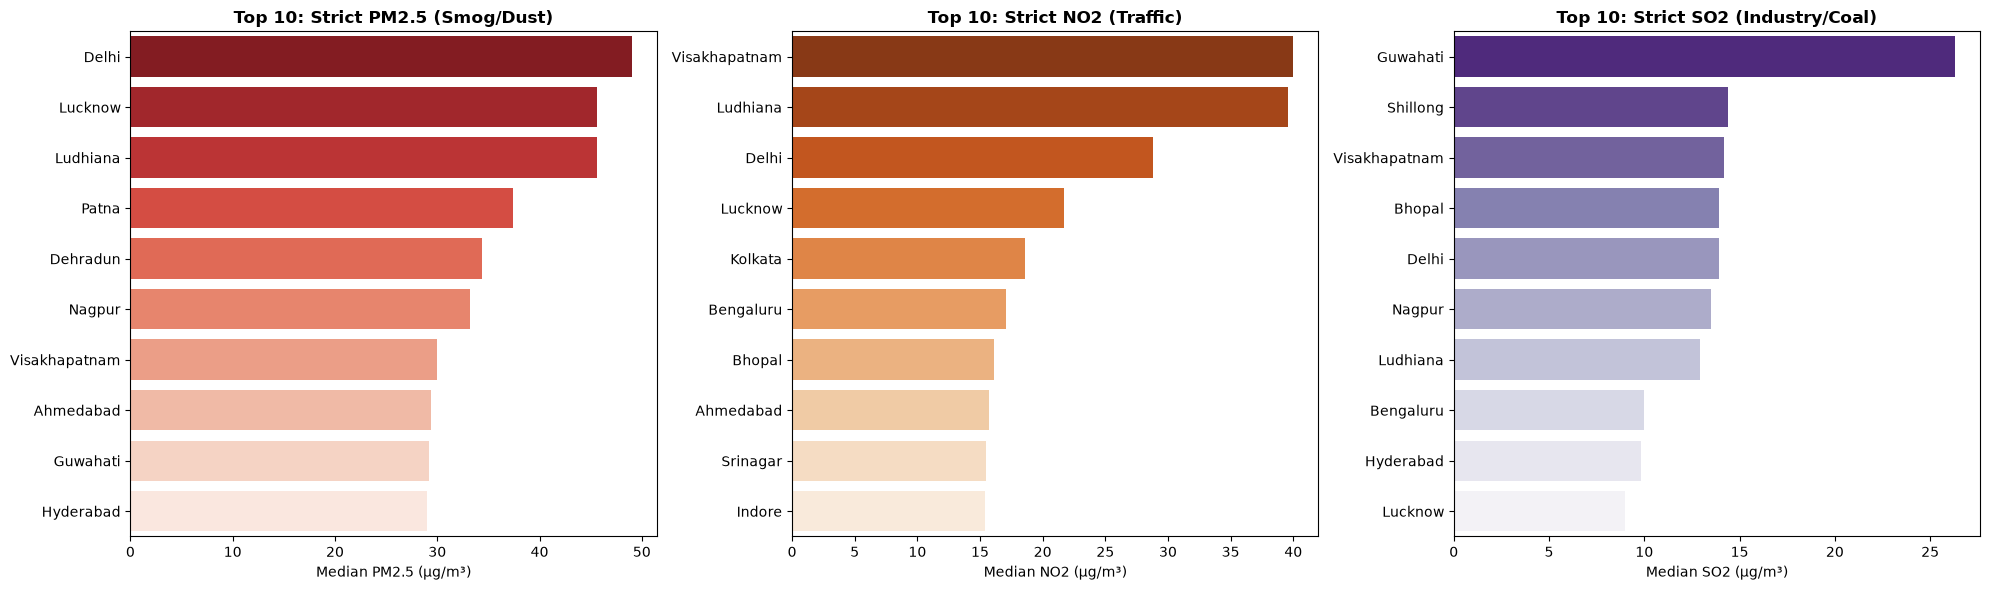

In [12]:
# --- THE ULTIMATE RIGOROUS EDA PIPELINE (FINAL DRAFT) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# 1. Connect to Postgres
load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

# 2. Query the HOURLY staging data
query = """
    SELECT city, station, pollutant, pollutant_value, reading_time_utc 
    FROM stg_aqi_readings 
    WHERE pollutant IN ('NO2', 'SO2', 'PM2.5')
"""
df_hourly = pd.read_sql(query, engine)

# ==============================================================================
# STAGE 1: Ensure Hourly Uniqueness & Calculate Completeness
# ==============================================================================
# Convert to datetime and create floor columns for Day and Hour
df_hourly['reading_time_utc'] = pd.to_datetime(df_hourly['reading_time_utc'], utc=True)
df_hourly['reading_hour'] = df_hourly['reading_time_utc'].dt.floor('h')
df_hourly['reading_date'] = df_hourly['reading_time_utc'].dt.floor('D')

# Deduplicate: Keep only the last reading per sensor per hour
df_hourly = (
    df_hourly
    .sort_values('reading_time_utc')
    .drop_duplicates(
        subset=['city', 'station', 'pollutant', 'reading_hour'],
        keep='last'
    )
)

# Group by individual sensor and day to get the daily mean and active hour count
sensor_daily = df_hourly.groupby(['city', 'station', 'pollutant', 'reading_date']).agg(
    daily_mean=('pollutant_value', 'mean'),
    hourly_counts=('reading_hour', 'nunique')
).reset_index()

# RULE: A sensor must have reported in at least 18 distinct hours (~75% coverage)
MIN_HOURS_PER_DAY = 18
sensor_daily_valid = sensor_daily[sensor_daily['hourly_counts'] >= MIN_HOURS_PER_DAY]


# ==============================================================================
# STAGE 2: City-Day Median
# ==============================================================================
# Find the typical sensor reading for the city on that day, and count active sensors
city_daily = sensor_daily_valid.groupby(['city', 'pollutant', 'reading_date']).agg(
    city_day_median=('daily_mean', 'median'),
    active_sensors=('station', 'nunique')
).reset_index()


# ==============================================================================
# STAGE 3: Period Distribution & Evidence Depth
# ==============================================================================
final_eda = city_daily.groupby(['city', 'pollutant']).agg(
    median_conc=('city_day_median', 'median'),
    mean_conc=('city_day_median', 'mean'),
    p90_conc=('city_day_median', lambda x: x.quantile(0.90)),
    p95_conc=('city_day_median', lambda x: x.quantile(0.95)),
    avg_active_sensors=('active_sensors', 'mean'),
    valid_day_count=('reading_date', 'nunique'),
    total_sensor_days=('active_sensors', 'sum')
).reset_index()

# Clean up formatting for display
for col in ['median_conc', 'mean_conc', 'p90_conc', 'p95_conc']:
    final_eda[col] = final_eda[col].round(1)
final_eda['avg_active_sensors'] = final_eda['avg_active_sensors'].round(1)

# Separate into dataframes for easier viewing
pm25_results = final_eda[final_eda['pollutant'] == 'PM2.5'].sort_values(by='median_conc', ascending=False)
no2_results  = final_eda[final_eda['pollutant'] == 'NO2'].sort_values(by='median_conc', ascending=False)
so2_results  = final_eda[final_eda['pollutant'] == 'SO2'].sort_values(by='median_conc', ascending=False)

# --- DISPLAY TABLES ---
print("🌫️ STRICT PM2.5 RANKINGS (Smog/Dust)")
display(pm25_results.head(10).reset_index(drop=True))

print("\n🚗 STRICT NO2 RANKINGS (Traffic/Vehicle Pollution)")
display(no2_results.head(10).reset_index(drop=True))

print("\n🏭 STRICT SO2 RANKINGS (Industrial/Coal Pollution)")
display(so2_results.head(10).reset_index(drop=True))


# ==============================================================================
# STAGE 4: Visualize the Rigorous Results
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: PM2.5
sns.barplot(x='median_conc', y='city', data=pm25_results.head(10), palette='Reds_r', ax=axes[0])
axes[0].set_title("Top 10: Strict PM2.5 (Smog/Dust)", fontweight='bold')
axes[0].set_xlabel("Median PM2.5 (µg/m³)")
axes[0].set_ylabel("")

# Plot 2: NO2
sns.barplot(x='median_conc', y='city', data=no2_results.head(10), palette='Oranges_r', ax=axes[1])
axes[1].set_title("Top 10: Strict NO2 (Traffic)", fontweight='bold')
axes[1].set_xlabel("Median NO2 (µg/m³)")
axes[1].set_ylabel("")

# Plot 3: SO2
sns.barplot(x='median_conc', y='city', data=so2_results.head(10), palette='Purples_r', ax=axes[2])
axes[2].set_title("Top 10: Strict SO2 (Industry/Coal)", fontweight='bold')
axes[2].set_xlabel("Median SO2 (µg/m³)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

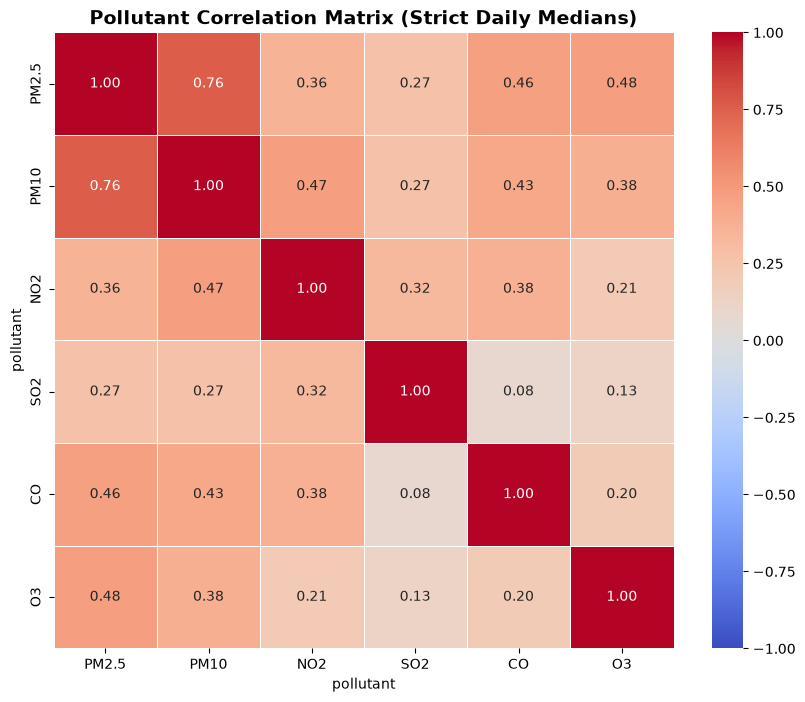

In [13]:
# --- RIGOROUS CORRELATION MATRIX ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# 1. Connect to Postgres
load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

# Pull all major pollutants for correlation
query = """
    SELECT city, station, pollutant, pollutant_value, reading_time_utc 
    FROM stg_aqi_readings 
    WHERE pollutant IN ('PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'NH3')
"""
df_hourly = pd.read_sql(query, engine)

# 2. Hourly Uniqueness & Date
df_hourly['reading_time_utc'] = pd.to_datetime(df_hourly['reading_time_utc'], utc=True)
df_hourly['reading_hour'] = df_hourly['reading_time_utc'].dt.floor('h')
df_hourly['reading_date'] = df_hourly['reading_time_utc'].dt.floor('D')

# Deduplicate identical hours
df_hourly = df_hourly.sort_values('reading_time_utc').drop_duplicates(
    subset=['city', 'station', 'pollutant', 'reading_hour'], keep='last'
)

# 3. Sensor-Day Mean & Completeness (>18 hours rule)
sensor_daily = df_hourly.groupby(['city', 'station', 'pollutant', 'reading_date']).agg(
    daily_mean=('pollutant_value', 'mean'),
    hourly_counts=('reading_hour', 'nunique')
).reset_index()

sensor_daily_valid = sensor_daily[sensor_daily['hourly_counts'] >= 18]

# 4. City-Day Median
city_daily = sensor_daily_valid.groupby(['city', 'pollutant', 'reading_date'])['daily_mean'].median().reset_index()

# 5. Pivot for Correlation
# We need rows to be (city, date) and columns to be the pollutants
df_pivot = city_daily.pivot(index=['city', 'reading_date'], columns='pollutant', values='daily_mean').reset_index()

# 6. Plot Heatmap
plt.figure(figsize=(10, 8))
# Filter to only the columns that actually exist in the pivot table to avoid KeyError
available_gases = [p for p in ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'NH3'] if p in df_pivot.columns]
corr_matrix = df_pivot[available_gases].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Pollutant Correlation Matrix (Strict Daily Medians)", fontsize=14, fontweight='bold')
plt.show()

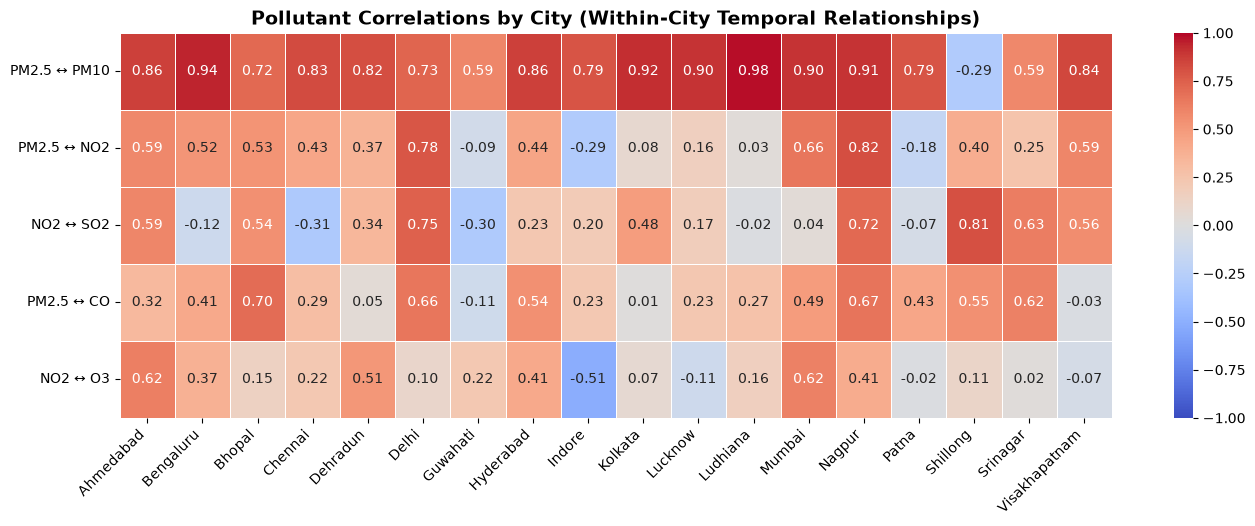

📝 INSIGHT: Notice how PM2.5 ↔ PM10 is almost universally high across all cities, proving a strong physical link.
But look at PM2.5 ↔ NO2. The correlation likely changes wildly depending on the city, proving that the relationship between smog and traffic is heavily dependent on local geography and infrastructure!


In [14]:
# ==============================================================================
# RIGOROUS CROSS-CITY CORRELATION ANALYSIS (Avoiding Simpson's Paradox)
# ==============================================================================
import numpy as np

# 1. Initialize storage for our city-specific matrices
city_correlations = {}
valid_cities = []

# 2. Calculate independent correlation matrices for each city
for city, group in df_pivot.groupby('city'):
    city_data = group[available_gases]
    
    # STRICT RULE: Only calculate if the city has at least 30 valid days of data
    if len(city_data) >= 30:
        city_correlations[city] = city_data.corr()
        valid_cities.append(city)

# 3. Define the specific relationships (pairs) we want to investigate across cities
key_pairs = [
    ('PM2.5', 'PM10'),  # The "Dust & Smog" baseline (should be high everywhere)
    ('PM2.5', 'NO2'),   # Smog vs. Traffic Exhaust
    ('NO2', 'SO2'),     # Traffic vs. Industry
    ('PM2.5', 'CO'),    # Smog vs. Incomplete Combustion
    ('NO2', 'O3')       # The Photochemical relationship (O3 is formed from NO2 + sunlight)
]

# 4. Build the comparison matrix
comparison_data = []

for pair in key_pairs:
    gas1, gas2 = pair
    # Ensure both gases exist in our dataset before extracting
    if gas1 in available_gases and gas2 in available_gases:
        row = {'Relationship': f"{gas1} ↔ {gas2}"}
        
        for city in valid_cities:
            # Extract the specific correlation value for this city
            # Using try/except in case a city is entirely missing one of the gases
            try:
                corr_val = city_correlations[city].loc[gas1, gas2]
            except KeyError:
                corr_val = np.nan
            row[city] = corr_val
            
        comparison_data.append(row)

# Convert to DataFrame and set the index
df_city_corr = pd.DataFrame(comparison_data).set_index('Relationship')

# Drop any cities that didn't have enough intersecting gas data
df_city_corr = df_city_corr.dropna(axis=1, how='all')

# 5. Visualize the Within-City Temporal Relationships
plt.figure(figsize=(16, 5))
sns.heatmap(df_city_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5, center=0)
plt.title("Pollutant Correlations by City (Within-City Temporal Relationships)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel("")
plt.show()

print("📝 INSIGHT: Notice how PM2.5 ↔ PM10 is almost universally high across all cities, proving a strong physical link.")
print("But look at PM2.5 ↔ NO2. The correlation likely changes wildly depending on the city, proving that the relationship between smog and traffic is heavily dependent on local geography and infrastructure!")

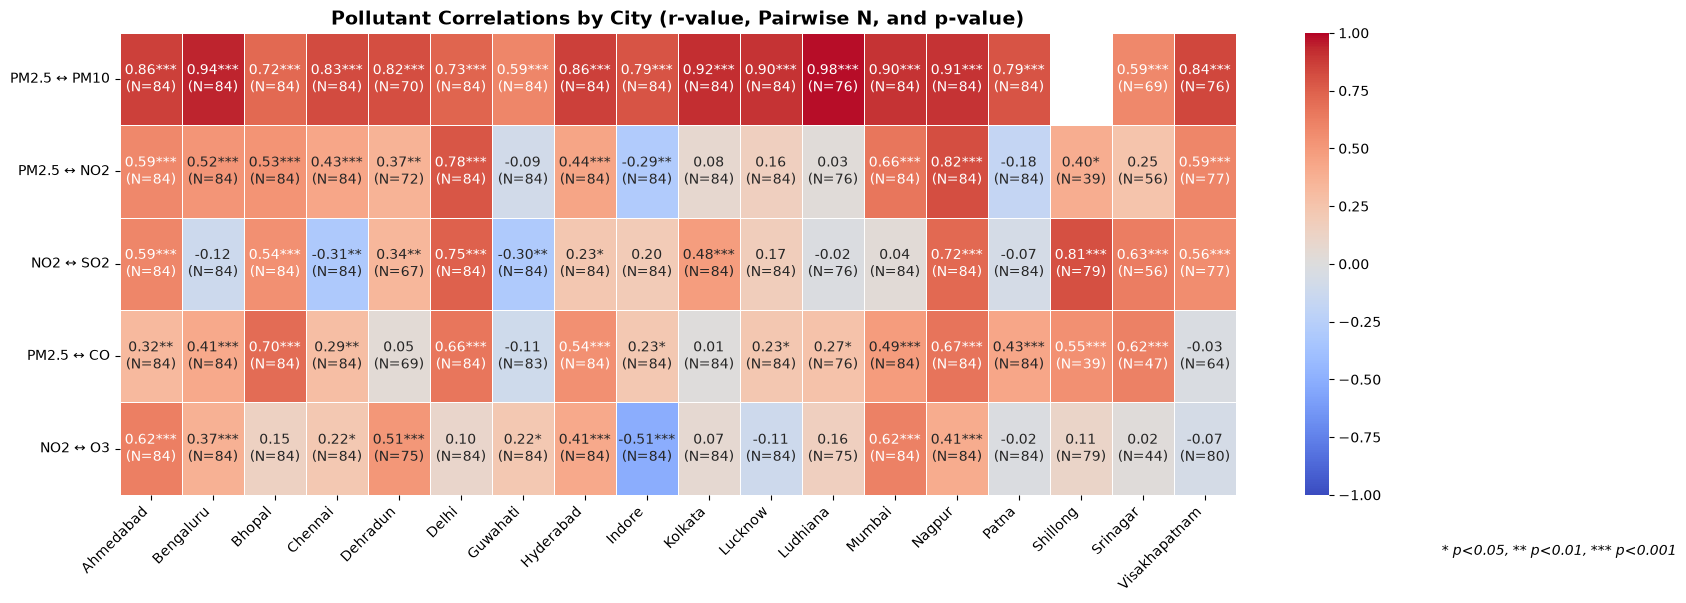

📝 STATISTICAL INSIGHT:
We are no longer just looking at numbers; we are looking at statistical confidence.
If a city shows a high correlation but lacks stars (p > 0.05), it means the relationship is statistically indistinguishable from random noise.


In [ ]:
# ==============================================================================
# RIGOROUS CROSS-CITY CORRELATION ANALYSIS (With p-values and safe alignment)
# ==============================================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

key_pairs = [
    ('PM2.5', 'PM10'),  # Dust & Smog
    ('PM2.5', 'NO2'),   # Smog vs. Traffic Exhaust
    ('NO2', 'SO2'),     # Traffic vs. Industry
    ('PM2.5', 'CO'),    # Smog vs. Incomplete Combustion
    ('NO2', 'O3')       # Photochemistry (NO2 destruction -> O3 creation)
]

# 1. Initialize lists to hold row dictionaries
corr_data = []
annot_data = []

# Only attempt cities that have at least 30 days of data in general
valid_cities = [c for c in df_pivot['city'].unique() if len(df_pivot[df_pivot['city'] == c]) >= 30]

for pair in key_pairs:
    gas1, gas2 = pair
    if gas1 in available_gases and gas2 in available_gases:
        r_row = {'Relationship': f"{gas1} ↔ {gas2}"}
        annot_row = {}  # Using a dict maps city names to annotations perfectly
        
        for city in valid_cities:
            city_data = df_pivot[df_pivot['city'] == city]
            
            # Find the strict Pairwise N (days where BOTH gases have non-null values)
            valid_pairs = city_data[[gas1, gas2]].dropna()
            n_val = len(valid_pairs)
            
            if n_val >= 30: # STRICT RULE: Minimum 30 paired observations
                # Calculate Pearson r and the p-value
                r_val, p_val = pearsonr(valid_pairs[gas1], valid_pairs[gas2])
                r_row[city] = r_val
                
                # Assign academic significance stars
                stars = ""
                if p_val < 0.001:
                    stars = "***"
                elif p_val < 0.01:
                    stars = "**"
                elif p_val < 0.05:
                    stars = "*"
                
                annot_row[city] = f"{r_val:.2f}{stars}\n(N={n_val})"
            else:
                r_row[city] = np.nan
                annot_row[city] = "NaN"
                
        corr_data.append(r_row)
        annot_data.append(annot_row)

# 2. Safely align matrices using DataFrame indices (The Production Fix)
df_corr = pd.DataFrame(corr_data).set_index('Relationship').dropna(axis=1, how='all')

# Create the annotation DataFrame and use .loc to guarantee perfect column/row alignment
annot_df = pd.DataFrame(annot_data, index=df_corr.index)
annot_df = annot_df.loc[df_corr.index, df_corr.columns]

# 3. Visualize the Statistical Heatmap
plt.figure(figsize=(18, 6))
sns.heatmap(
    df_corr, 
    annot=annot_df, 
    fmt="", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5, 
    center=0
)
plt.title("Pollutant Correlations by City (r-value, Pairwise N, and p-value)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel("")

# Add a footnote explaining the stats
plt.figtext(0.99, 0.01, '* p<0.05, ** p<0.01, *** p<0.001', horizontalalignment='right', fontsize=10, style='italic')

plt.show()

print("📝 STATISTICAL INSIGHT:")
print("We are no longer just looking at numbers; we are looking at statistical confidence.")
print("If a city shows a high correlation but lacks stars (p > 0.05), non-significant results such as in this case could mean the observed correlation is not sufficiently supported by this sample to distinguish it from zero at the chosen significance level.")

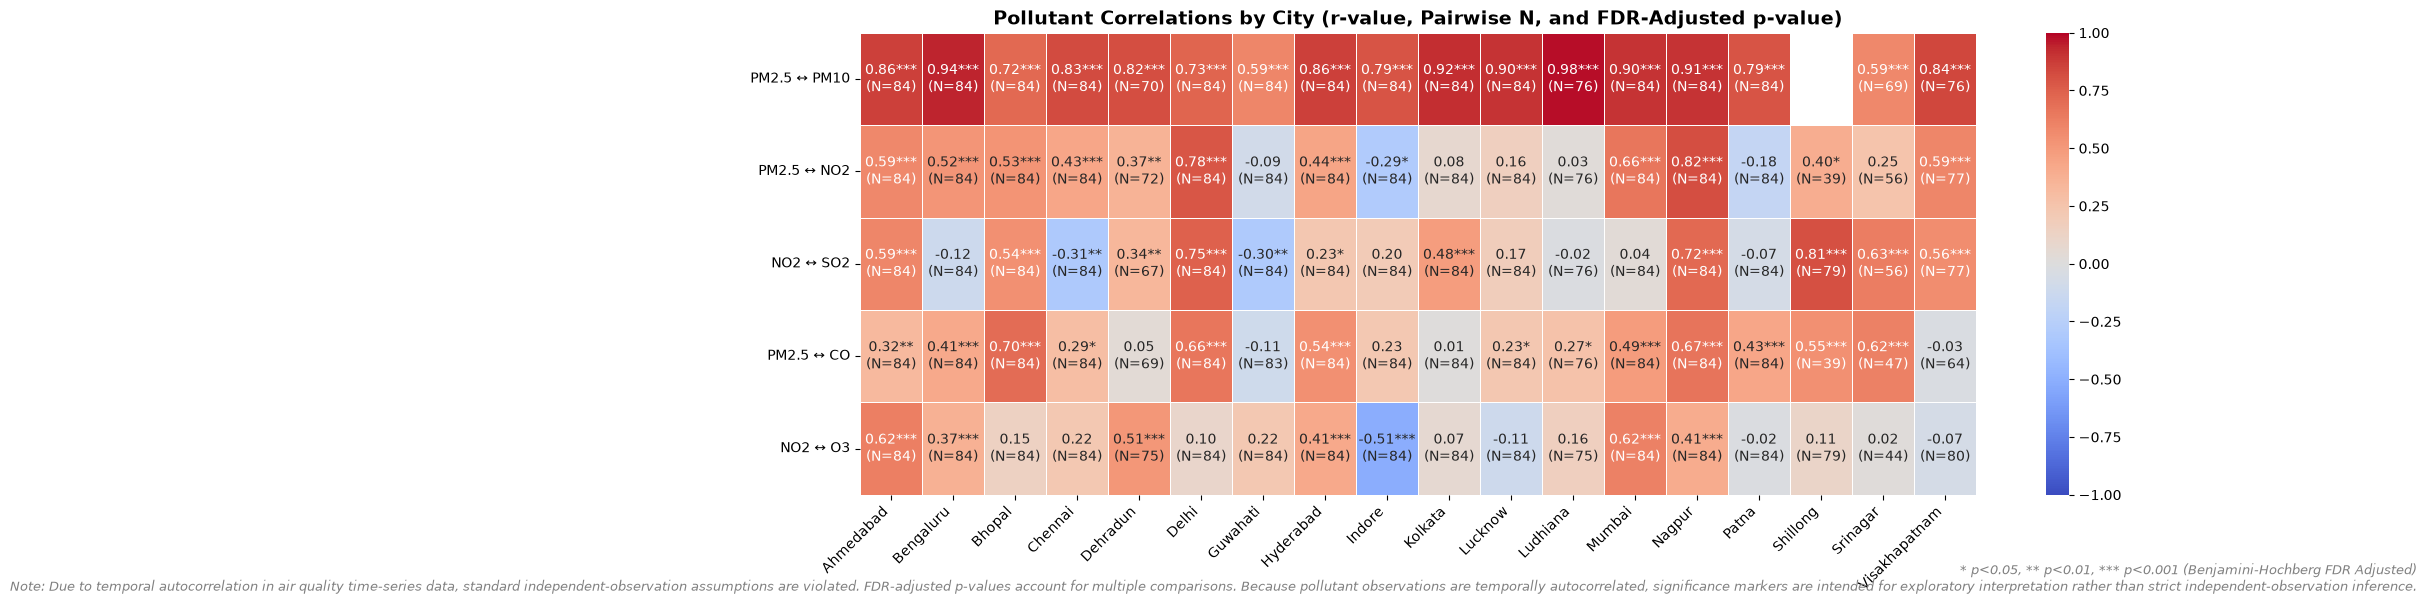

In [19]:
# ==============================================================================
# RIGOROUS CORRELATION ANALYSIS (With FDR-Adjusted p-values & Pairwise N)
# ==============================================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

key_pairs = [
    ('PM2.5', 'PM10'),  # Dust & Smog
    ('PM2.5', 'NO2'),   # Smog vs. Traffic Exhaust
    ('NO2', 'SO2'),     # Traffic vs. Industry
    ('PM2.5', 'CO'),    # Smog vs. Incomplete Combustion
    ('NO2', 'O3')       # Photochemistry (NO2 destruction -> O3 creation)
]

valid_cities = [c for c in df_pivot['city'].unique() if len(df_pivot[df_pivot['city'] == c]) >= 30]

# 1. Collect all raw statistics first
raw_results = []

for pair in key_pairs:
    gas1, gas2 = pair
    if gas1 in available_gases and gas2 in available_gases:
        for city in valid_cities:
            # Get overlapping valid days for this specific city and gas pair
            valid_pairs = df_pivot[df_pivot['city'] == city][[gas1, gas2]].dropna()
            n_val = len(valid_pairs)
            
            if n_val >= 30: # STRICT RULE: Minimum 30 paired observations
                r_val, p_val = pearsonr(valid_pairs[gas1], valid_pairs[gas2])
                raw_results.append({
                    'pair': f"{gas1} ↔ {gas2}",
                    'city': city,
                    'r_val': r_val,
                    'p_raw': p_val,
                    'n_val': n_val
                })

results_df = pd.DataFrame(raw_results)

# 2. Apply Benjamini-Hochberg FDR correction to the p-values
# This protects us from the Multiple Comparisons trap across our ~80 tests
reject, p_adj, _, _ = multipletests(results_df['p_raw'], alpha=0.05, method='fdr_bh')
results_df['p_adj'] = p_adj

# 3. Build the safe, correctly-aligned matrices
corr_data = []
annot_data = []

for pair_name in results_df['pair'].unique():
    r_row = {'Relationship': pair_name}
    annot_row = {}
    
    pair_subset = results_df[results_df['pair'] == pair_name]
    
    for city in valid_cities:
        city_res = pair_subset[pair_subset['city'] == city]
        
        if not city_res.empty:
            r_val = city_res['r_val'].values[0]
            p_a = city_res['p_adj'].values[0]
            n_val = city_res['n_val'].values[0]
            
            # Apply stars based on the ADJUSTED p-value
            stars = ""
            if p_a < 0.001: stars = "***"
            elif p_a < 0.01: stars = "**"
            elif p_a < 0.05: stars = "*"
            
            r_row[city] = r_val
            annot_row[city] = f"{r_val:.2f}{stars}\n(N={n_val})"
        else:
            r_row[city] = np.nan
            annot_row[city] = "NaN"
            
    corr_data.append(r_row)
    annot_data.append(annot_row)

df_corr = pd.DataFrame(corr_data).set_index('Relationship').dropna(axis=1, how='all')
annot_df = pd.DataFrame(annot_data, index=df_corr.index).loc[df_corr.index, df_corr.columns]

# 4. Visualize the Heatmap
plt.figure(figsize=(18, 6))
sns.heatmap(
    df_corr, 
    annot=annot_df, 
    fmt="", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5, 
    center=0
)
plt.title("Pollutant Correlations by City (r-value, Pairwise N, and FDR-Adjusted p-value)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel("")

# Footnote acknowledging the statistical rigor
footnote = (
    "* p<0.05, ** p<0.01, *** p<0.001 (Benjamini-Hochberg FDR Adjusted)\n"
    "Note: Due to temporal autocorrelation in air quality time-series data, standard independent-observation assumptions are violated. "
    "FDR-adjusted p-values account for multiple comparisons. Because pollutant observations are temporally autocorrelated, significance markers are intended for exploratory interpretation rather than strict independent-observation inference."
)
plt.figtext(0.99, -0.05, footnote, horizontalalignment='right', fontsize=9, style='italic', color='gray')

plt.show()

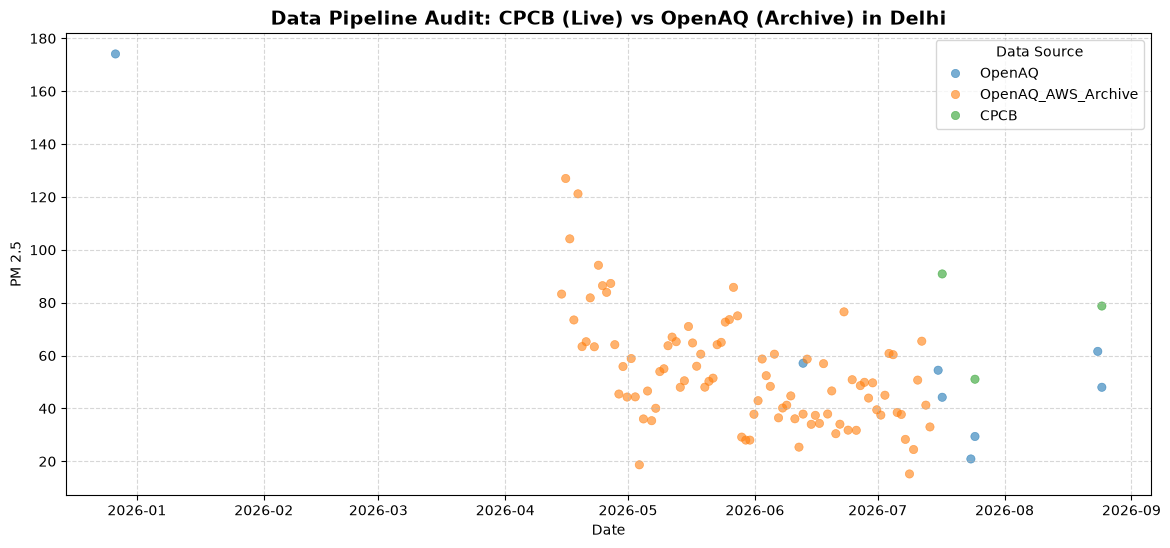

📝 INSIGHT 4: Plotting both sources validates our pipeline. The AWS Archive (OpenAQ) provides dense historical clusters, while CPCB provides our recent live data edge.


In [7]:
# --- CELL 5 ---
plt.figure(figsize=(14, 6))

# Filter for just Delhi from the RAW table to keep the 'source' column
delhi_sources = df_raw[df_raw['city'] == 'Delhi'].dropna(subset=['avg_pm25'])

sns.scatterplot(data=delhi_sources, x='reading_date', y='avg_pm25', hue='source', alpha=0.6, edgecolor=None)
plt.title("Data Pipeline Audit: CPCB (Live) vs OpenAQ (Archive) in Delhi", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("PM 2.5")
plt.legend(title="Data Source")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("📝 INSIGHT 4: Plotting both sources validates our pipeline. The AWS Archive (OpenAQ) provides dense historical clusters, while CPCB provides our recent live data edge.")